<a href="https://colab.research.google.com/github/sunilchhajwani/ChatGPT/blob/v2-dev/unsupervised_learning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install scikit-learn pandas numpy matplotlib seaborn umap-learn


In [2]:
import numpy as np
import pandas as pd
np.random.seed(42)

n = 1000
age = np.random.randint(20, 90, n)
sex = np.random.choice([0,1], size=n)  # 0 female, 1 male
# vitals
systolic = np.random.normal(125, 15, n)
diastolic = np.random.normal(78, 10, n)
hr = np.random.normal(78, 12, n)
temp = np.random.normal(36.8, 0.5, n)
rr = np.random.normal(16, 2.5, n)
# labs
wbc = np.random.normal(7, 2, n)
hgb = np.random.normal(13.5, 1.8, n)
glucose = np.random.normal(105, 30, n)
creatinine = np.random.normal(1.0, 0.25, n)

# simulate a clinical subgroup (e.g., infection + hypertension)
sub_idx = np.random.choice(n, size=int(0.12*n), replace=False)
systolic[sub_idx] += np.random.normal(25,5, sub_idx.size)
wbc[sub_idx] += np.random.normal(6,2, sub_idx.size)
glucose[sub_idx] += np.random.normal(30,8, sub_idx.size)

# inject a few anomalies
out_idx = np.random.choice(n, size=int(0.02*n), replace=False)
systolic[out_idx] += np.random.normal(80,10, out_idx.size)
wbc[out_idx] += np.random.normal(20,5, out_idx.size)
creatinine[out_idx] += np.random.normal(2.5,0.7, out_idx.size)

df = pd.DataFrame({
    'age': age, 'sex': sex,
    'systolic': systolic, 'diastolic': diastolic, 'hr': hr, 'rr': rr, 'temp': temp,
    'wbc': wbc, 'hgb': hgb, 'glucose': glucose, 'creatinine': creatinine
})

# add random missingness
for col in df.columns:
    df.loc[df.sample(frac=0.02).index, col] = np.nan

df.head()


,age,sex,systolic,diastolic,hr,rr,temp,wbc,hgb,glucose,creatinine
0,71.0,1.0,132.865070,86.375079,93.011454,16.560008,37.767341,14.281823,17.196010,156.944288,0.904767
1,34.0,0.0,102.311067,91.068741,80.714746,19.527513,36.262847,4.726198,15.237319,153.378116,1.078328
2,80.0,0.0,100.449125,84.481373,90.028998,19.129226,37.080446,7.352159,12.533031,50.606404,1.069356
3,40.0,0.0,143.085372,85.558550,91.016714,17.849065,36.173304,9.065552,15.730220,66.921158,0.977281
4,43.0,0.0,147.420329,77.015610,64.565331,17.819280,36.368483,10.539554,12.430861,145.157389,0.748932


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['sex'].plot(kind='hist', bins=20, title='sex')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['systolic'].plot(kind='hist', bins=20, title='systolic')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['diastolic']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('diastolic')

from matplotlib import pyplot as plt
_df_12['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['age'].plot(kind='line', figsize=(8, 4), title='age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['sex'].plot(kind='line', figsize=(8, 4), title='sex')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['systolic'].plot(kind='line', figsize=(8, 4), title='systolic')
plt.gca().spines[['top', 'right']].set_visible(False)

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
df.to_csv('/content/drive/MyDrive/my_health_dataset.csv', index=False)


In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
from ipywidgets import Dropdown
from IPython.display import display

base_path = "/content/drive/MyDrive/"
file_list = []

# Recursively search for CSV & Excel files
for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.endswith(".csv") or f.endswith(".xlsx"):
            file_list.append(os.path.join(root, f))

print("Total files found:", len(file_list))

# Create dropdown to select file
file_selector = Dropdown(options=file_list, description='Select File:')
display(file_selector)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total files found: 7


Dropdown(description='Select File:', options=('/content/drive/MyDrive/taxpnl zerodha kite.xlsx', '/content/dri…

In [12]:
# ============================================
# 3. Load Selected Dataset
# ============================================
filepath = file_selector.value
print("Loading:", filepath)

if filepath.endswith(".csv"):
    df = pd.read_csv(filepath)
else:
    df = pd.read_excel(filepath)

print("Dataset Loaded Successfully!")
df.head()


Loading: /content/drive/MyDrive/my_health_dataset.csv
Dataset Loaded Successfully!


,age,sex,systolic,diastolic,hr,rr,temp,wbc,hgb,glucose,creatinine
0,71.0,1.0,132.865070,86.375079,93.011454,16.560008,37.767341,14.281823,17.196010,156.944288,0.904767
1,34.0,0.0,102.311067,91.068741,80.714746,19.527513,36.262847,4.726198,15.237319,153.378116,1.078328
2,80.0,0.0,100.449125,84.481373,90.028998,19.129226,37.080446,7.352159,12.533031,50.606404,1.069356
3,40.0,0.0,143.085372,85.558550,91.016714,17.849065,36.173304,9.065552,15.730220,66.921158,0.977281
4,43.0,0.0,147.420329,77.015610,64.565331,17.819280,36.368483,10.539554,12.430861,145.157389,0.748932


In [14]:
# Drop missing values
df = df.dropna()

# Keep only numeric columns
df_num = df.select_dtypes(include=['float64', 'int64'])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

print("Data shape after preprocessing:", X_scaled.shape)


Data shape after preprocessing: (805, 11)


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA completed!")


PCA completed!


In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = labels
df.head()


,age,sex,systolic,diastolic,hr,rr,temp,wbc,hgb,glucose,creatinine,Cluster
0,71.0,1.0,132.865070,86.375079,93.011454,16.560008,37.767341,14.281823,17.196010,156.944288,0.904767,2
1,34.0,0.0,102.311067,91.068741,80.714746,19.527513,36.262847,4.726198,15.237319,153.378116,1.078328,0
2,80.0,0.0,100.449125,84.481373,90.028998,19.129226,37.080446,7.352159,12.533031,50.606404,1.069356,0
3,40.0,0.0,143.085372,85.558550,91.016714,17.849065,36.173304,9.065552,15.730220,66.921158,0.977281,0
4,43.0,0.0,147.420329,77.015610,64.565331,17.819280,36.368483,10.539554,12.430861,145.157389,0.748932,0


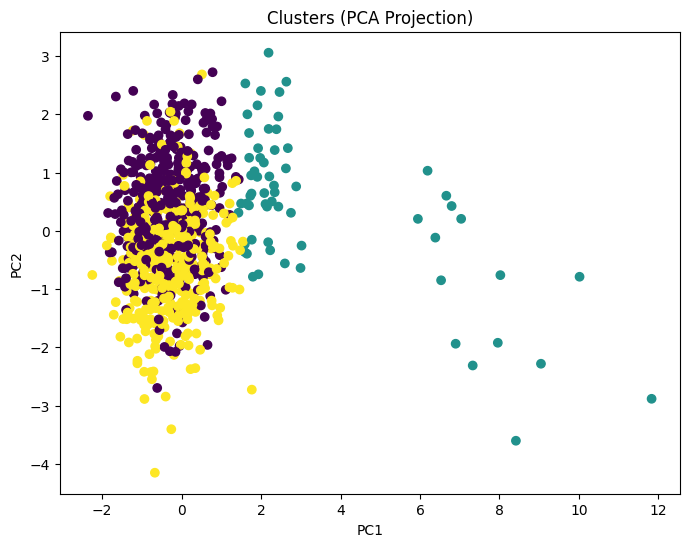

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [18]:
df['Cluster'] = labels


In [19]:
cluster_summary = df.groupby('Cluster').mean()
cluster_summary


,age,sex,systolic,diastolic,hr,rr,temp,wbc,hgb,glucose,creatinine
Cluster,,,,,,,,,,,
0,53.863158,0.000000,126.337145,78.013428,77.679467,16.152215,36.820632,7.283561,13.330939,104.450339,0.994485
1,52.666667,0.380952,169.199322,80.870111,74.577143,16.358529,36.854293,17.145208,13.814708,131.022456,1.615505
2,54.430939,1.000000,126.699253,78.795524,78.175105,16.000852,36.794178,7.313512,13.579150,104.985865,1.006890


from matplotlib import pyplot as plt
cluster_summary['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
cluster_summary['sex'].plot(kind='hist', bins=20, title='sex')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
cluster_summary['systolic'].plot(kind='hist', bins=20, title='systolic')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
cluster_summary['diastolic'].plot(kind='hist', bins=20, title='diastolic')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['sex']
  ys = series['hr']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = cluster_summary.sort_values('sex', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('sex')
_ = plt.ylabel('hr')

from matplotlib import pyplot as plt
cluster_summary['age'].plot(kind='line', figsize=(8, 4), title='age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
cluster_summary['sex'].plot(kind='line', figsize=(8, 4), title='sex')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
cluster_summary['systolic'].plot(kind='line', figsize=(8, 4), title='systolic')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
cluster_summary['diastolic'].plot(kind='line', figsize=(8, 4), title='diastolic')
plt.gca().spines[['top', 'right']].set_visible(False)

In [20]:
# Use your already loaded dataframe 'df'
df_num = df.select_dtypes(include=['float64', 'int64'])   # numeric variables only
df_num.head()


,age,sex,systolic,diastolic,hr,rr,temp,wbc,hgb,glucose,creatinine
0,71.0,1.0,132.865070,86.375079,93.011454,16.560008,37.767341,14.281823,17.196010,156.944288,0.904767
1,34.0,0.0,102.311067,91.068741,80.714746,19.527513,36.262847,4.726198,15.237319,153.378116,1.078328
2,80.0,0.0,100.449125,84.481373,90.028998,19.129226,37.080446,7.352159,12.533031,50.606404,1.069356
3,40.0,0.0,143.085372,85.558550,91.016714,17.849065,36.173304,9.065552,15.730220,66.921158,0.977281
4,43.0,0.0,147.420329,77.015610,64.565331,17.819280,36.368483,10.539554,12.430861,145.157389,0.748932


In [21]:
import numpy as np
import pandas as pd

corr = df_num.corr()
corr


,age,sex,systolic,diastolic,hr,rr,temp,wbc,hgb,glucose,creatinine
age,1.000000,0.006175,-0.070804,-0.016244,0.020181,0.001891,0.025208,-0.043970,-0.040009,-0.018506,-0.016499
sex,0.006175,1.000000,-0.016627,0.022058,0.017680,-0.044634,-0.025649,-0.008727,0.071875,-0.003028,0.033249
systolic,-0.070804,-0.016627,1.000000,0.032328,-0.055416,0.012494,-0.000655,0.529773,0.035873,0.100313,0.371117
diastolic,-0.016244,0.022058,0.032328,1.000000,0.013842,-0.004234,0.024118,0.059304,0.011405,-0.025601,0.037665
hr,0.020181,0.017680,-0.055416,0.013842,1.000000,-0.065701,-0.010102,-0.029188,-0.013931,0.022941,-0.007480
rr,0.001891,-0.044634,0.012494,-0.004234,-0.065701,1.000000,-0.008565,0.024233,0.025505,0.074807,-0.028923
temp,0.025208,-0.025649,-0.000655,0.024118,-0.010102,-0.008565,1.000000,-0.021308,-0.034950,0.047928,-0.021477
wbc,-0.043970,-0.008727,0.529773,0.059304,-0.029188,0.024233,-0.021308,1.000000,0.065429,0.154307,0.469500
hgb,-0.040009,0.071875,0.035873,0.011405,-0.013931,0.025505,-0.034950,0.065429,1.000000,0.017666,0.007281
glucose,-0.018506,-0.003028,0.100313,-0.025601,0.022941,0.074807,0.047928,0.154307,0.017666,1.000000,-0.022878


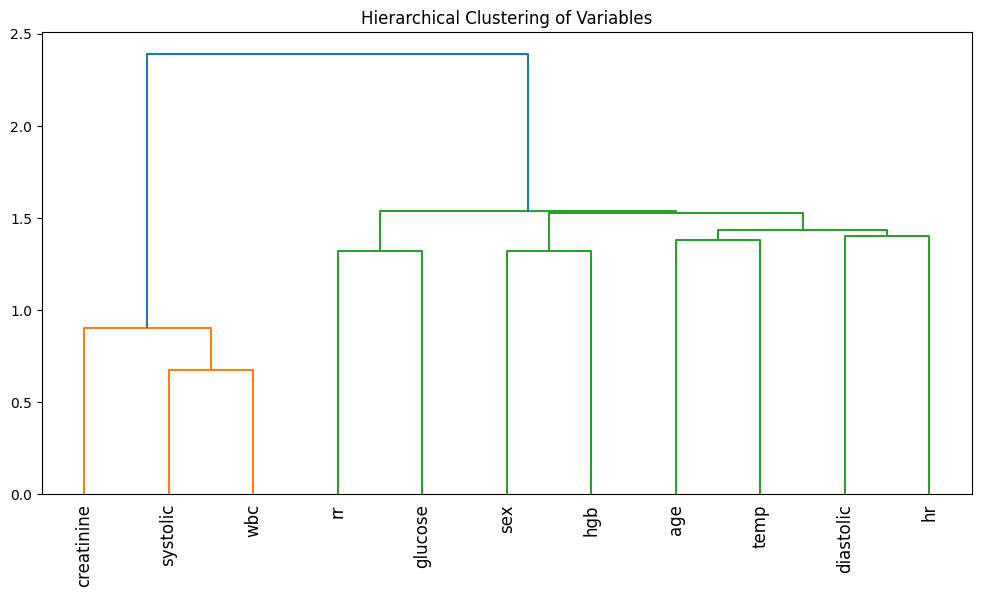

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
Z = linkage(corr, method='ward')

dendrogram(Z, labels=corr.columns, leaf_rotation=90)
plt.title("Hierarchical Clustering of Variables")
plt.show()


In [23]:
!pip install umap-learn


In [24]:
import pandas as pd

# keep only numeric variables for clustering
df_num = df.select_dtypes(include=['float64', 'int64']).copy()

print("Numeric data shape:", df_num.shape)
df_num.head()


Numeric data shape: (805, 11)


,age,sex,systolic,diastolic,hr,rr,temp,wbc,hgb,glucose,creatinine
0,71.0,1.0,132.865070,86.375079,93.011454,16.560008,37.767341,14.281823,17.196010,156.944288,0.904767
1,34.0,0.0,102.311067,91.068741,80.714746,19.527513,36.262847,4.726198,15.237319,153.378116,1.078328
2,80.0,0.0,100.449125,84.481373,90.028998,19.129226,37.080446,7.352159,12.533031,50.606404,1.069356
3,40.0,0.0,143.085372,85.558550,91.016714,17.849065,36.173304,9.065552,15.730220,66.921158,0.977281
4,43.0,0.0,147.420329,77.015610,64.565331,17.819280,36.368483,10.539554,12.430861,145.157389,0.748932


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)


In [29]:
import umap

reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

print("UMAP shape:", X_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (805, 2)


In [31]:
from sklearn.cluster import KMeans

k = 3  # choose 2–6 depending on dataset
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels


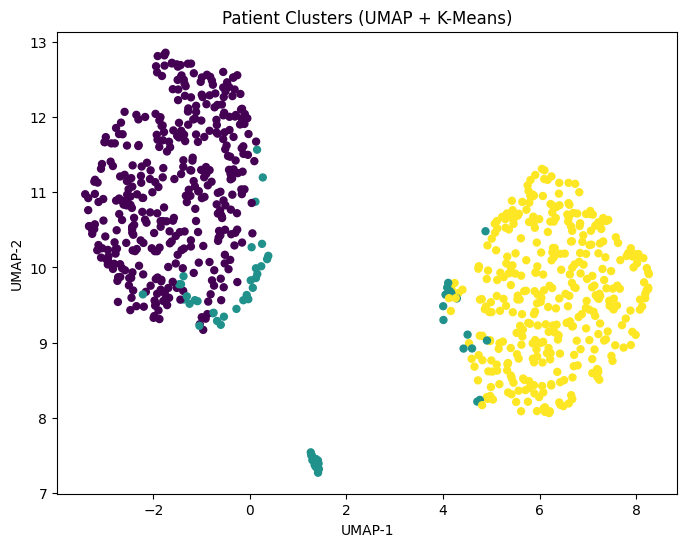

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, s=25)
plt.title("Patient Clusters (UMAP + K-Means)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


In [33]:
cluster_summary = df_num.copy()
cluster_summary["Cluster"] = labels

summary = cluster_summary.groupby("Cluster").mean().round(2)
summary


,age,sex,systolic,diastolic,hr,rr,temp,wbc,hgb,glucose,creatinine
Cluster,,,,,,,,,,,
0,53.86,0.00,126.34,78.01,77.68,16.15,36.82,7.28,13.33,104.45,0.99
1,52.67,0.38,169.20,80.87,74.58,16.36,36.85,17.15,13.81,131.02,1.62
2,54.43,1.00,126.70,78.80,78.18,16.00,36.79,7.31,13.58,104.99,1.01


In [34]:
importance = {}

for c in range(k):
    cluster_mean = summary.loc[c]
    overall_mean = df_num.mean()

    diff = (cluster_mean - overall_mean).abs().sort_values(ascending=False)
    importance[c] = diff.index[:5]   # top 5 influential variables

importance


{0: Index(['systolic', 'glucose', 'wbc', 'diastolic', 'sex'], dtype='object'),
 1: Index(['systolic', 'glucose', 'wbc', 'hr', 'diastolic'], dtype='object'),
 2: Index(['systolic', 'glucose', 'wbc', 'sex', 'hr'], dtype='object')}

In [35]:
print("=== Clinical Interpretation of Patient Clusters ===\n")

for c in range(k):
    print(f"Cluster {c} — Key Characteristics:")

    vars_top = importance[c]

    for v in vars_top:
        cluster_mean = summary.loc[c, v]
        overall_mean = df_num[v].mean()

        direction = "HIGHER" if cluster_mean > overall_mean else "LOWER"
        print(f" • {v}: {direction} than population average")

    print("\n")


=== Clinical Interpretation of Patient Clusters ===

Cluster 0 — Key Characteristics:
 • systolic: LOWER than population average
 • glucose: LOWER than population average
 • wbc: LOWER than population average
 • diastolic: LOWER than population average
 • sex: LOWER than population average


Cluster 1 — Key Characteristics:
 • systolic: HIGHER than population average
 • glucose: HIGHER than population average
 • wbc: HIGHER than population average
 • hr: LOWER than population average
 • diastolic: HIGHER than population average


Cluster 2 — Key Characteristics:
 • systolic: LOWER than population average
 • glucose: LOWER than population average
 • wbc: LOWER than population average
 • sex: HIGHER than population average
 • hr: HIGHER than population average


